In [ ]:
import osmnx as ox
import geopandas as gpd

PLACE = "Espoo, Finland"

# Tags for elementary / primary schools in OSM
# - amenity=school (general schools)
# - school=elementary / school=primary (more specific when present)
tags = {
    "amenity": "school",
}

# Pull matching features
espoo_pop = ox.features_from_place(PLACE, tags)

# Keep only point/polygon/line features we can locate; many will be polygons
espoo_pop = espoo_pop[espoo_pop.geometry.notna()].copy()

# Convert everything to a point location for mapping/analysis
# (polygons -> representative point inside polygon)
espoo_pop["location"] = espoo_pop.geometry.representative_point()

schools_pts = espoo_pop.set_geometry("location").copy()

keep_cols = [c for c in ['amenity', 'education', 'grades', 'loc_name', 'name', "addr:street", "addr:housenumber", "addr:postcode", "website"] if c in schools_pts.columns]
schools_pts = schools_pts[keep_cols + ["location"]].rename(columns={"location": "geometry"}).set_geometry("geometry")

print(schools_pts.head())

                   amenity education grades loc_name  \
element id                                             
node    162617718   school    school  11-13   Kunkku   
        247223630   school       NaN    NaN     Etis   
        5036388895  school    school    NaN      NaN   
        5128702327  school       NaN    NaN      NaN   
        5496386501  school       NaN    NaN      NaN   

                                          name          addr:street  \
element id                                                            
node    162617718          Kuninkaantien lukio  Kaivomestarinniitty   
        247223630         Etelä-Tapiolan lukio         Ahertajantie   
        5036388895      Lasten montessorikoulu            Kirvuntie   
        5128702327  FQ21 Koulutus&Konsultointi        Rajamaankaari   
        5496386501                       Omnia            Kuunkehrä   

                   addr:housenumber addr:postcode  \
element id                                          
nod

In [2]:
schools_pts.explore()

In [3]:
from routingpy import Valhalla
from pprint import pprint
import shapely
import contextily as cx
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import pandas as pd

# CATCHMENT_AREAS = [5, 10, 15, 20, 25, 30]
CATCHMENT_AREAS = [5, 10, 15, 20]

# MODES_OF_TRANSPORTATION = ['pedestrian']
MODES_OF_TRANSPORTATION = ['bicycle']
# MODES_OF_TRANSPORTATION = ['pedestrian', 'bicycle', 'auto']
# MODES_OF_TRANSPORTATION = ['pedestrian', 'bicycle']

def calculate_isochrones(latlons, catchment_areas = CATCHMENT_AREAS):
    MAX_INTERVALS = 4 # Valhalla API limit: maximum number of intervals per request
    
    client = Valhalla(retry_over_query_limit=True)

    # Nested dictionary structure:
    # {mode_of_transport: {time_interval: [list_of_polygons]}}
    isochrones_by_trans_by_time = {}

    # Split catchment areas into chunks of size <= MAX_INTERVALS
    # Example: [5,10,15,20,25,30] → [[5,10,15,20],[25,30]]
    chunked_catchments_areas = [
        catchment_areas[i:i + MAX_INTERVALS]
        for i in range(0, len(catchment_areas), MAX_INTERVALS)
    ]
    
    for chunked_catchment_area in chunked_catchments_areas:
        for latlon in latlons:
            for mode_of_transport in MODES_OF_TRANSPORTATION:
                # Convert minutes → seconds because Valhalla expects seconds
                # Example: [5,10] → [300,600]
                isochrones = client.isochrones(
                    locations=latlon,
                    profile=mode_of_transport,
                    intervals=[c * 60 for c in chunked_catchment_area],
                    interval_type='time',
                    polygons=True
                )
        
                for iso in isochrones:
                        isochrones_by_trans_by_time.setdefault(mode_of_transport, {}).setdefault(iso.interval, []).append(Polygon(iso.geometry[0])) # iso.geometry[0] extracts the outer ring of the polygon
                    
    # Merge (union) polygons that share the same mode and time threshold
    # This combines overlapping isochrones from multiple origins
    for mode_of_transport, isochrones_by_time in isochrones_by_trans_by_time.items():
        for time, polygons in isochrones_by_time.items():
            isochrones_by_trans_by_time[mode_of_transport][time] = shapely.union_all(polygons)

    # Flatten nested dictionary into tabular format
    # Each row represents one (mode, time, geometry)
    df = pd.DataFrame(
        [
            (mode_of_transport, time, polygon)
            for mode_of_transport, isochrones_by_time in isochrones_by_trans_by_time.items()
            for time, polygon in isochrones_by_time.items()
        ],
        columns=["mode_of_transportation", "time", "geometry"]
    )

    final_isochrones = gpd.GeoDataFrame(df, crs="EPSG:4326").sort_values(by="time", ascending=False)
    
    return final_isochrones

In [4]:
schools_pts.head()

amenity education grades loc_name  \
element id                                             
node    162617718   school    school  11-13   Kunkku   
        247223630   school       NaN    NaN     Etis   
        5036388895  school    school    NaN      NaN   
        5128702327  school       NaN    NaN      NaN   
        5496386501  school       NaN    NaN      NaN   

                                          name          addr:street  \
element id                                                            
node    162617718          Kuninkaantien lukio  Kaivomestarinniitty   
        247223630         Etelä-Tapiolan lukio         Ahertajantie   
        5036388895      Lasten montessorikoulu            Kirvuntie   
        5128702327  FQ21 Koulutus&Konsultointi        Rajamaankaari   
        5496386501                       Omnia            Kuunkehrä   

                   addr:housenumber addr:postcode  \
element id                                          
node    162617718                 2         02770   
        247223630                 5         02120   
        5036388895               22         02140   
        5128702327                7         02970   
        5496386501                2         02210   

                                                  website  \
element id                                                  
node    162617718       http://www.kuninkaantie.espoo.fi/   
        247223630            http://www.etela-tapiola.fi/   
        5036388895  https://www.laajalahdenmontessori.fi/   
        5128702327                                    NaN   
        5496386501                                    NaN   

                                     geometry  
element id                                     
node    162617718   POINT (24.65998 60.20986)  
        247223630   POINT (24.79339 60.17828)  
        5036388895  POINT (24.80466 60.20398)  
        5128702327  POINT (24.76446 60.29522)  
        5496386501  POINT (24.72502 60.17305)

In [5]:
school_latlons = list(
    zip(schools_pts.geometry.x,
        schools_pts.geometry.y)
)

In [6]:
school_isochrones = calculate_isochrones(school_latlons)
school_isochrones.sort_values("time", ascending=False)

c:\Users\fonta\repos\geospatial_challenge_camp\venv\Lib\site-packages\routingpy\client_default.py:215: UserWarning: Rate limit exceeded.
Retrying for the 1st time.
  warnings.warn(
c:\Users\fonta\repos\geospatial_challenge_camp\venv\Lib\site-packages\routingpy\client_default.py:215: UserWarning: Rate limit exceeded.
Retrying for the 2nd time.
  warnings.warn(
c:\Users\fonta\repos\geospatial_challenge_camp\venv\Lib\site-packages\routingpy\client_default.py:215: UserWarning: Rate limit exceeded.
Retrying for the 3rd time.
  warnings.warn(


,mode_of_transportation,time,geometry
3,bicycle,1200,"POLYGON ((24.72219 60.14487, 24.72215 60.14486..."
2,bicycle,900,"MULTIPOLYGON (((24.71054 60.14104, 24.70988 60..."
1,bicycle,600,"MULTIPOLYGON (((24.66964 60.12177, 24.66821 60..."
0,bicycle,300,"MULTIPOLYGON (((24.67319 60.15143, 24.67392 60..."


In [8]:
def save_isochrones(isochrones_gdf, city_name):
    for _, row in isochrones_gdf.iterrows():
        one = isochrones_gdf.loc[[row.name]]
    
        layer_name = f"mode_{row['mode_of_transportation']}_time_{int(row['time'])}"
        
        one.to_file(
            f'output/{city_name}_isochrones.gpkg',
            layer=layer_name,
            driver="GPKG"
        )

save_isochrones(school_isochrones, 'espoo')

In [9]:
school_isochrones.head()

,mode_of_transportation,time,geometry
3,bicycle,1200,"POLYGON ((24.72219 60.14487, 24.72215 60.14486..."
2,bicycle,900,"MULTIPOLYGON (((24.71054 60.14104, 24.70988 60..."
1,bicycle,600,"MULTIPOLYGON (((24.66964 60.12177, 24.66821 60..."
0,bicycle,300,"MULTIPOLYGON (((24.67319 60.15143, 24.67392 60..."


In [10]:
school_isochrones.explore()

In [11]:
espoo = ox.geocode_to_gdf("Espoo, Finland")
espoo = espoo.to_crs(4326)

m = espoo.explore(
    tiles="CartoDB positron",
    color="black",
    style_kwds={"fillColor": "lightblue", "fillOpacity": 0.2, "weight": 2},
    name="Espoo boundary",
)

m = school_isochrones.explore(
    m=m,
    column="time",
    cmap="YlOrRd",
    legend=True,
    style_kwds={"fillOpacity": 0.35, "weight": 1},
    tooltip=["time"],
    name="Isochrones",
)

m = schools_pts.explore(
    m=m,
    color="blue",
    marker_kwds={"radius": 2},
    tooltip=["name"],
    name="School",
)

m

In [20]:
def calculate_population_catchments(pop_gdf, isochrones):
    rows = []
    
    total_population = pop_gdf.population_sum.sum()

    for trans_mode in MODES_OF_TRANSPORTATION:
        isochrones_for_mode = isochrones[isochrones['mode_of_transportation'] == trans_mode]
        for _, iso in isochrones_for_mode.iterrows():
            pop_cells_in_isochrone = pop_gdf[pop_gdf.intersects(iso.geometry)]
            pop_in_iso = pop_cells_in_isochrone.population_sum.sum()
            
            rows.append({
                "mode_of_transportation": trans_mode,
                "time": iso.time,
                "time_min": iso.time / 60,
                "population_share": pop_in_iso / total_population
            })
    
    population_catchment = (
        pd.DataFrame(rows)
        .sort_values(["mode_of_transportation", "time"])
        .reset_index(drop=True)
    )

    return population_catchment

In [21]:
import geopandas as gpd
from pathlib import Path

fp = Path(r"output\espoo_children_population.geojson")

espoo_pop = gpd.read_file(fp)

espoo_pop = espoo_pop.to_crs(4326)

espoo_pop.head()

,pop_0,pop_1,pop_5,pop_10,pop_15,population_sum,geometry
0,0.000702,0.002996,0.003958,0.004473,0.004420,0.016549,"POLYGON ((24.665 60.36333, 24.665 60.3625, 24...."
1,0.002151,0.009184,0.012135,0.013712,0.013550,0.050732,"POLYGON ((24.65 60.36083, 24.65 60.36, 24.6508..."
2,0.001255,0.005356,0.007077,0.007997,0.007902,0.029587,"POLYGON ((24.65083 60.36083, 24.65083 60.36, 2..."
3,0.001000,0.004271,0.005643,0.006377,0.006301,0.023592,"POLYGON ((24.65167 60.36083, 24.65167 60.36, 2..."
4,0.001408,0.006010,0.007941,0.008973,0.008867,0.033199,"POLYGON ((24.6525 60.36083, 24.6525 60.36, 24...."


In [22]:
espoo_child_population_catchment = calculate_population_catchments(espoo_pop, school_isochrones)

In [23]:
espoo_child_population_catchment.to_csv(
    "output/espoo_child_population_catchment.csv",
    index=False
)

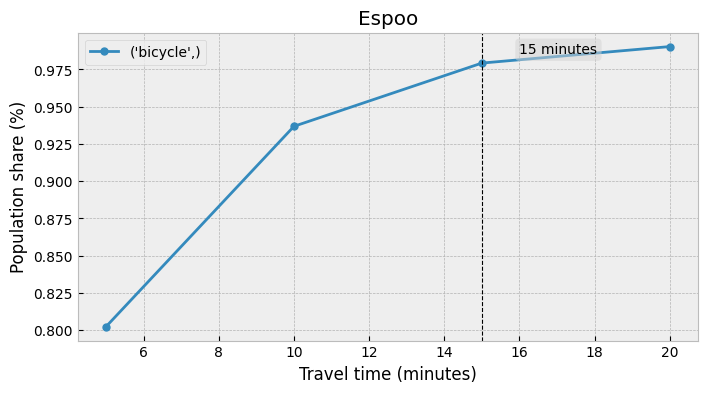

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('bmh')

fig, ax = plt.subplots(figsize=(8,4))

# Plot each line and give it a label
for (mode), g in espoo_child_population_catchment.groupby(["mode_of_transportation"]):
    ax.plot(
        g["time_min"],
        g["population_share"],
        marker="o",
        markersize=5,
        label=f"{mode}"  # ← add a label so legend shows
    )

# Vertical line at 15 minutes
ax.axvline(x=15, color='black', linestyle='--', linewidth=0.8)

# "15 minutes" label with transparent grey box
ax.text(
    x=15 + 1, 
    y=ax.get_ylim()[0]+0.2, 
    s="15 minutes", 
    color='black', 
    rotation=0, 
    va='top', 
    ha='left',
    bbox=dict(facecolor='lightgrey', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.3')
)

ax.set_xlabel("Travel time (minutes)")
ax.set_ylabel("Population share (%)")
ax.set_title("Espoo", color='black')

# Show legend
legend = ax.legend()
plt.setp(legend.get_texts(), color='black')
plt.setp(legend.get_title(), color='black')

fig.savefig(f"output/child_population_accessibility_potential_espoo.png", dpi=300, bbox_inches='tight', facecolor='#e7e7e7')

plt.show()
